In [2]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
import os
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf
# https://www.youtube.com/watch?v=qiUEgSCyY5o

In [3]:
from torch.utils.data import TensorDataset, DataLoader
columns = ['inv_mass','d_len','pt_cand','d_len_xy']


def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)


with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    print(os.path.getsize(r"Training_Data\FD.root"))
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    features = torch.tensor(pd.DataFrame(training_data_FD).values)

dataset = TensorDataset(features)     # No labels
loader = DataLoader(dataset, batch_size=2000, shuffle=True)

print(features.shape)

with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file_test:
    print(os.path.getsize(r"Training_Data\data.root"))
    tree_test = file_test['treeMLDplus']
    tree_test.show()
    branches_test = tree_test.keys()
    print(branches_test)
    training_data_bkg = tree_test.arrays(branches_test, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg)
    features_test = torch.tensor(training_data_bkg_df.values)[:10000]
dataset_test = TensorDataset(features_test)     # No labels
loader_test = DataLoader(dataset_test, batch_size=2000, shuffle=True)
print(features_test.shape)
print(features[0,:]-features_test[0,:])


402333
name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | A

5772 10000


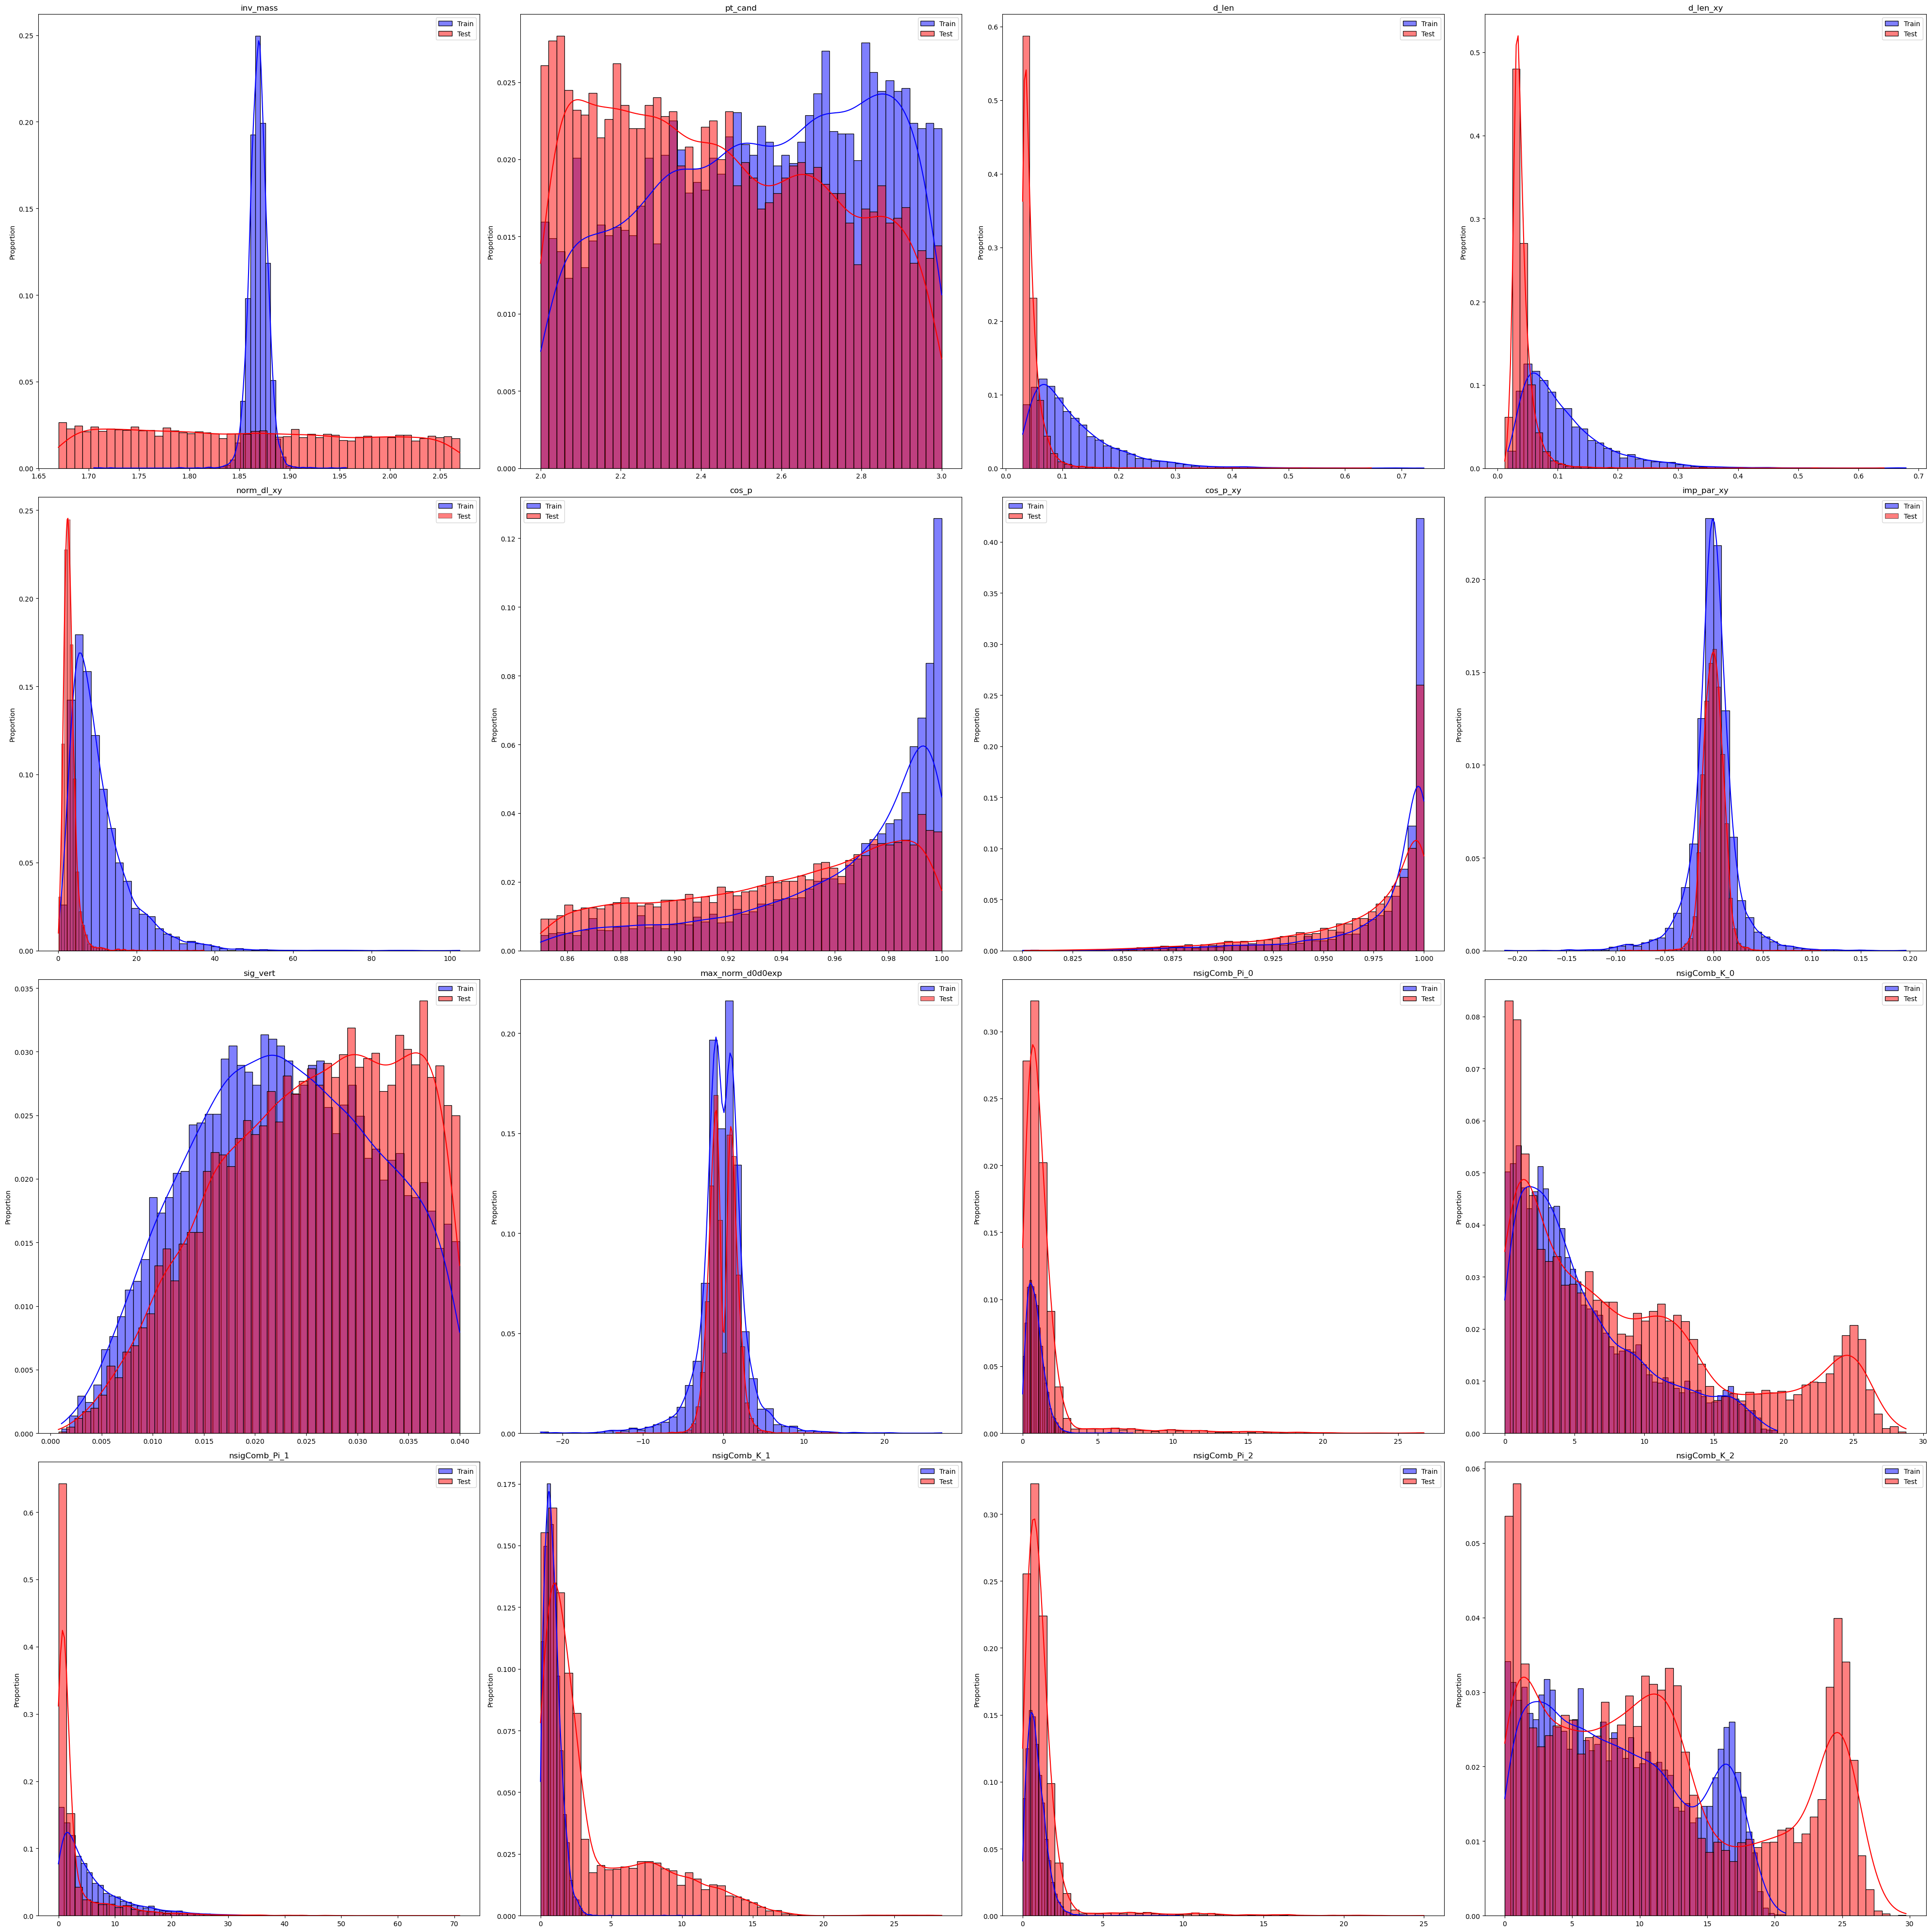

In [4]:
import seaborn as sns
def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)
# Convert train and test loaders
train_tensor = loader_to_tensor(loader)
test_tensor = loader_to_tensor(loader_test)
print(len(train_tensor),len(test_tensor))
# Convert to numpy for plotting
train_np = train_tensor.numpy()
test_np = test_tensor.numpy()

# Column names
columns = branches

# Plot histograms for each feature
fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(train_np[:, i], bins=50, color='blue', alpha=0.5, label='Train', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(test_np[:, i], bins=50, color='red', alpha=0.5, label='Test', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

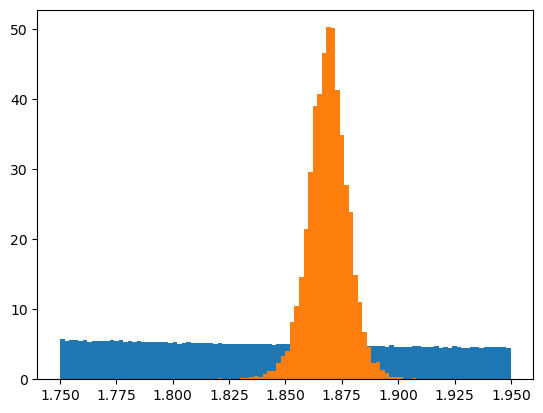

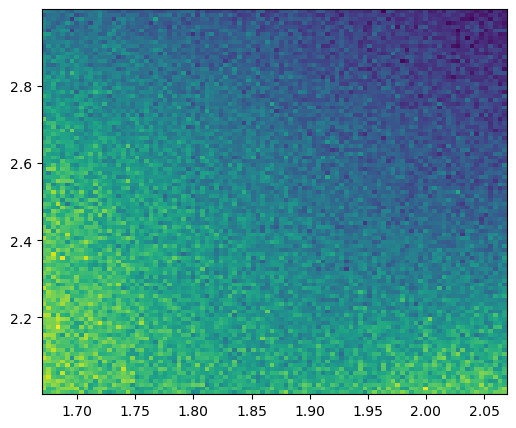

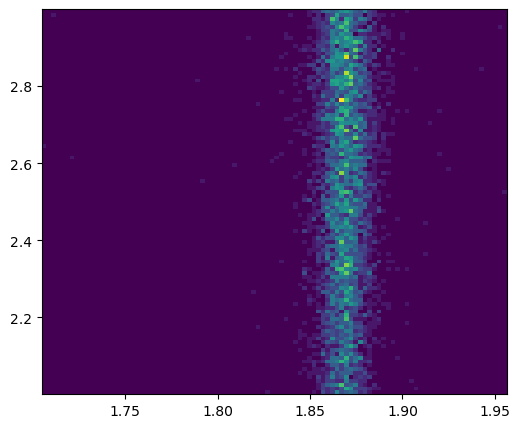

In [5]:
plt.hist(training_data_bkg['inv_mass'],range=[1.75,1.95],bins=100,density=True)
plt.hist(training_data_FD['inv_mass'],range=[1.75,1.95],bins=100,density=True)

fig, ax = plt.subplots(figsize=(6, 5))

# plt.hist([embedded1D,embedded1D_test],bins=100)
ax.hist2d(training_data_bkg['inv_mass'],training_data_bkg['pt_cand'],bins=[100,100])

plt.show()
fig, ax = plt.subplots(figsize=(6, 5))

# plt.hist([embedded1D,embedded1D_test],bins=100)
ax.hist2d(training_data_FD['inv_mass'],training_data_FD['pt_cand'],bins=[100,100])

plt.show()


In [6]:
# Definieer een auto encoder neural network. Dit type neural network bgint met de volledige 16 parameters, comprimeert ze in steeds kleinere lagen
# Totdat het de kleinste laag van maar twee neuronen bereikt. Daarna probeert het hiermee weer de originele parameters te recreeëren
# Dit model leert dus voor het signaal van D+ deeltjes hoe de data er ongeveer uitziet. Het verschil tussen de input en output parameters
# Voor D+ deeltjes zou dus heel klein moeten zijn, en de error dus klein. Maar het model is niet getrained op alle andere deeltjes.
# De verwachting is dus dat andere deeltjes die geen D+ deeltjes zijn, de autoencoder heel slecht zal zijn in de parameters recreeëren zonder extra training.
# Zo kan de error van het netwerk gebruikt worden als classificatie van wel of niet D+ deeltjes.

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU(),
            # nn.Linear(8, 4),
            # nn.ReLU(),
        )
        self.growing = nn.Sequential(
            # nn.Linear(4, 8),
            # nn.ReLU(),
            nn.Linear(8, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))


In [7]:
# model_8D = Autoencoder()
# loss_function = nn.MSELoss()
# optimizer = optim.Adam(model_8D.parameters(), lr=1e-3, weight_decay=1e-8)
# epochs = 3000
# outputs = []
# losses = []

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_8D.to(device)
# loss_vs_epoch = []
# for epoch in range(epochs):
#     total_loss = 0
#     for batch in loader:
#         features = batch[0].to(device)
        
#         reconstructed = model_8D(features)
#         loss = loss_function(reconstructed, features)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
#     loss_vs_epoch.append(total_loss)
#     outputs.append((epoch, features, reconstructed))
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(loss_vs_epoch, label='Loss')
# plt.xlabel('Iterations')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

In [8]:
# # Initialize a new model with smallest inner layer dimension 4 to train
# model_4D = Autoencoder4D()
# old_state = model_8D.state_dict()
# new_state = model_4D.state_dict()
# epochs = 6000
# # copy matching parameters
# for name, param in old_state.items():
#     if name in new_state and new_state[name].shape == param.shape:
#         new_state[name] = param

# # model_4D.load_state_dict(new_state)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model_4D.to(device)
# optimizer = optim.Adam(model_4D.parameters(), lr=1e-3, weight_decay=1e-8)

# for epoch in range(epochs):
#     total_loss = 0
#     for batch in loader:
#         features = batch[0].to(device)
        
#         reconstructed = model_4D(features)
#         loss = loss_function(reconstructed, features)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
#     loss_vs_epoch.append(total_loss)
#     outputs.append((epoch, features, reconstructed))
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")
    
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(loss_vs_epoch, label='Loss')
# plt.xlabel('Iterations')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

In [9]:
# # Find the error of the values in the dataset
# def compute_sample_errors(model, loader, device='cpu'):
#     model.eval()
#     model.to(device)

#     errors = []

#     with torch.no_grad():
#         for batch in loader:
#             x = batch[0].to(device).float()

#             recon = model(x)

#             # MSE per sample
#             # reduction='none' gives shape [batch, features]
#             sample_loss = torch.mean((x - recon)**2, dim=1)

#             errors.extend(sample_loss.cpu().numpy())

#     return np.array(errors)

# # Find the error in reconstructing the parameters. Should be large for parameters dissimilar to what we trained.
# def compute_average_reconstruction_error(model, loader, device='cpu'):
#     model.eval()
#     model.to(device)
#     total_loss = 0.0
#     n_samples = 0

#     with torch.no_grad():
#         for batch in loader:
#             x = batch[0].to(device).float()   # ensure dtype matches model
#             recon = model(x)
#             batch_loss = torch.mean((x - recon)**2, dim=1)  # per-sample MSE
#             total_loss += batch_loss.sum().item()
#             n_samples += x.size(0)

#     avg_loss = total_loss / n_samples
#     return avg_loss


# avg_error = compute_average_reconstruction_error(model_8D, loader_test)
# print(f"Average reconstruction error new: {avg_error:.6f}")
# avg_error = compute_average_reconstruction_error(model_8D, loader)
# print(f"Average reconstruction error training: {avg_error:.6f}")

# errors = [compute_sample_errors(model_8D, loader_test),compute_sample_errors(model_8D, loader)]

# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,5))
# plt.hist(errors[0], bins=50, range=[0,1], alpha=0.5, label='Test', density=True)
# plt.hist(errors[1], bins=50, range=[0,1], alpha=0.5, label='Train', density=True)
# plt.xlabel("Reconstruction Error")
# plt.ylabel("Frequency")
# plt.title("Autoencoder Reconstruction Error")
# plt.legend()
# plt.show()


In [10]:
# model_4D.eval()
# with torch.no_grad():
#     latent_normal = model_4D.shrinking(features.to(device).float()).cpu().numpy()  # latent codes

# from sklearn.neighbors import KernelDensity
# kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
# kde.fit(latent_normal)  

# model_4D.eval()
# with torch.no_grad():
#     latent_test = model_4D.shrinking(features_test.to(device).float()).cpu().numpy()
#     latent = model_4D.shrinking(features.to(device).float()).cpu().numpy()

# log_density = kde.score_samples(latent_test)  # evaluate density of test points
# log_density_labeled = kde.score_samples(latent)  # evaluate density of test points

# with torch.no_grad():
#     recon_test = model_4D(features_test.to(device).float())
#     recon_error = torch.mean((features_test.to(device).float() - recon_test)**2, dim=1).cpu().numpy()
#     recon = model_4D(features.to(device).float())
#     recon_error_labeled = torch.mean((features.to(device).float() - recon)**2, dim=1).cpu().numpy()

# anomaly_score = recon_error - log_density
# anomaly_score_labeled = recon_error_labeled - log_density_labeled
# plt.hist(anomaly_score,range=[0,5],density=True,bins=100)
# plt.hist(anomaly_score_labeled,range=[0,5],density=True,bins=100)

In [11]:
# embedded1D = model_1D.shrinking(features).detach().numpy()[:, 0]
# embedded1D_test = model_1D.shrinking(features_test).detach().numpy()[:, 0]

# embedded = model_2D.shrinking(features).detach().numpy()
# embedded_test = model_2D.shrinking(features_test).detach().numpy()
# fig, ax = plt.subplots(figsize=(6, 5))

# xmin, xmax = np.min(embedded[:, 0]), np.max(embedded[:, 0])
# ymin, ymax = np.min(embedded[:, 1]), np.max(embedded[:, 1])

# def plot_embedded(ax, embedded):    
#     p = ax.hist2d(embedded[:, 0], embedded[:, 1],
#                   bins=(10, 10), range=((xmin, xmax), (ymin, ymax)),
#                   norm=mpl.colors.LogNorm())
#     ax.axis([xmin, xmax, ymin, ymax])
#     return p

# # plt.hist([embedded1D,embedded1D_test],bins=100)
# p = plot_embedded(ax, embedded)

# fig.colorbar(p[-1], ax=ax, label="number of samples")
# plt.show()


# fig, ax = plt.subplots(figsize=(6, 5))
# p2 = plot_embedded(ax,embedded_test)
# fig.colorbar(p[-1], ax=ax, label="number of samples")

# plt.show()

In [12]:
# from sklearn.neighbors import KernelDensity


# model = model_4D
# # Encode all normal training data
# model.eval()
# with torch.no_grad():
#     latent = model.shrinking(features.to(device).float()).cpu().numpy()

# kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(latent)

# def anomaly_score(model, x, kde, device='cpu'):
#     model.eval()
#     x = x.to(device).float()
#     with torch.no_grad():
#         latent = model.shrinking(x).cpu().numpy()
#         recon = model(x)
#         recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
#         latent_density = kde.score_samples(latent)  # log-likelihood
#     # High error + low density → anomaly
#     score = recon_error - latent_density  # you can weight them differently
#     return latent_density

# # normal_data: Tensor, outlier_data: Tensor
# scores_normal = anomaly_score(model, features_test, kde)
# scores_outlier = anomaly_score(model, features, kde)

# # Choose threshold that maximizes F1 or TPR/FPR tradeoff
# from sklearn.metrics import roc_auc_score, precision_recall_curve

# y_true = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_outlier))])
# y_scores = np.concatenate([scores_normal, scores_outlier])

# roc_auc = roc_auc_score(y_true, y_scores)
# precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
# plt.hist(scores_normal,range=[-5,0])
# plt.hist(scores_outlier,range=[-5,0])

Epoch 1/500, Loss: 80.775810
Epoch 2/500, Loss: 80.162117
Epoch 3/500, Loss: 79.705477
Epoch 4/500, Loss: 79.185749
Epoch 5/500, Loss: 78.878420
Epoch 6/500, Loss: 78.318922
Epoch 7/500, Loss: 77.658775
Epoch 8/500, Loss: 77.142784
Epoch 9/500, Loss: 76.423443
Epoch 10/500, Loss: 75.681910
Epoch 11/500, Loss: 74.895916
Epoch 12/500, Loss: 73.819386
Epoch 13/500, Loss: 72.981977
Epoch 14/500, Loss: 71.748213
Epoch 15/500, Loss: 70.500994
Epoch 16/500, Loss: 69.026138
Epoch 17/500, Loss: 67.383068
Epoch 18/500, Loss: 65.491362
Epoch 19/500, Loss: 63.493431
Epoch 20/500, Loss: 61.157797
Epoch 21/500, Loss: 58.645189
Epoch 22/500, Loss: 56.080135
Epoch 23/500, Loss: 53.175526
Epoch 24/500, Loss: 50.273355
Epoch 25/500, Loss: 47.351503
Epoch 26/500, Loss: 44.238049
Epoch 27/500, Loss: 41.224537
Epoch 28/500, Loss: 38.310805
Epoch 29/500, Loss: 35.535803
Epoch 30/500, Loss: 33.066833
Epoch 31/500, Loss: 30.848036
Epoch 32/500, Loss: 28.921131
Epoch 33/500, Loss: 27.420811
Epoch 34/500, Loss:

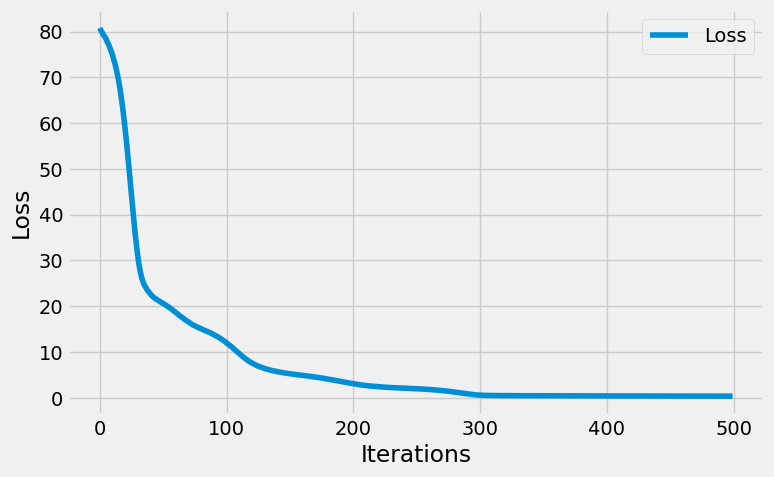

In [13]:
model_2D = Autoencoder()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model_2D.parameters(), lr=1e-3, weight_decay=1e-8)
epochs = 500
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2D.to(device)
loss_vs_epoch = []
loader_2D = loader


for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        features = batch[0].to(device)
        
        reconstructed = model_2D(features)
        loss = loss_function(reconstructed, features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    loss_vs_epoch.append(total_loss)
    outputs.append((epoch, features, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_vs_epoch, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

variance of layer 73.90437


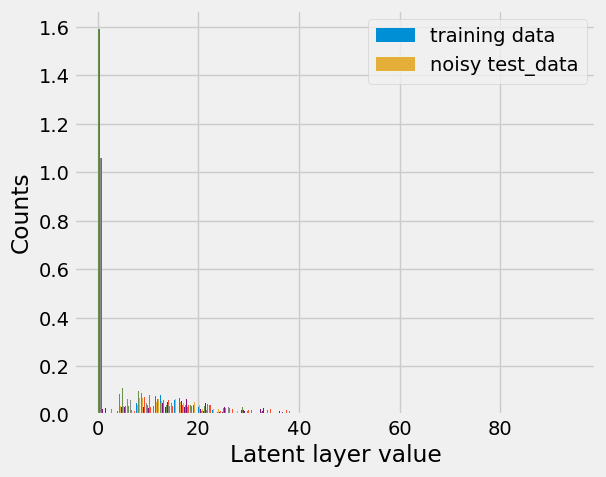

C:\Users\sande\AppData\Local\Temp\ipykernel_17364\1652842382.py:61: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(latent_test[:, i], color='blue', alpha=0.5, label='Train', ax=axes[i])
C:\Users\sande\AppData\Local\Temp\ipykernel_17364\1652842382.py:62: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(latent_train[:, i], color='red', alpha=0.5, label='Test', ax=axes[i])
C:\Users\sande\AppData\Local\Temp\ipykernel_17364\1652842382.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


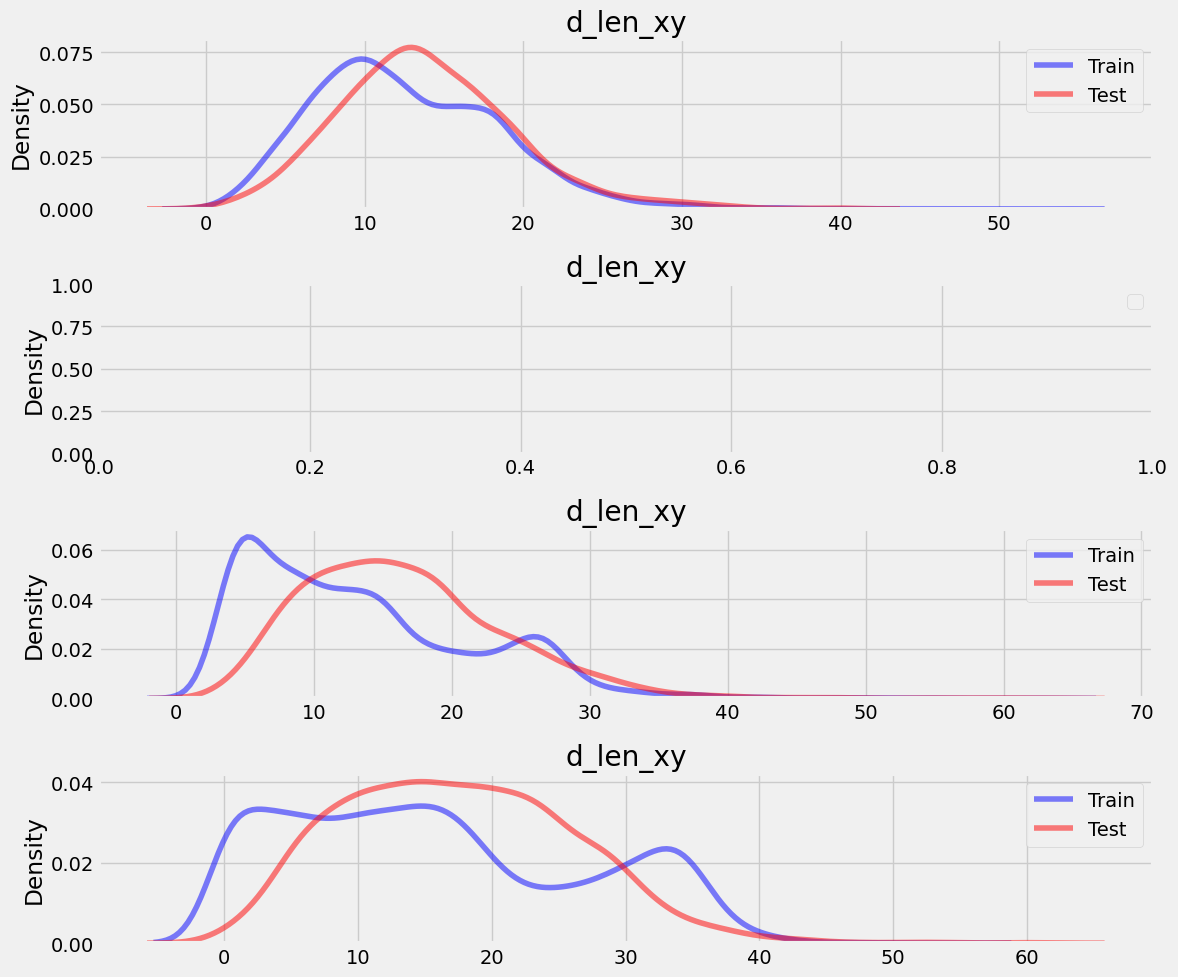

mean squared error:  0.104588784
mean squared error:  2.3430898


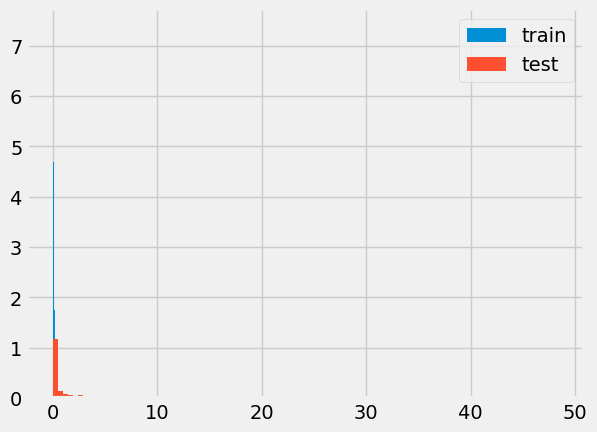

In [21]:
from sklearn.neighbors import KernelDensity


model = model_2D
# Encode all normal training data
model.eval()
with torch.no_grad():
    latent = model.shrinking(features.to(device).float()).cpu().numpy()
    latent_test = model.shrinking(features_test.to(device).float()).cpu().numpy()


print("variance of layer", np.var(latent[:,3]))
fig, ax = plt.subplots(figsize=(6, 5))
plt.hist(latent,bins=100,density=True,label='training data')

plt.hist(latent_test,bins=100,density=True, label='noisy test_data')
# latent_test_mask = latent_test > 0.42
# print(len(latent_test[latent_test_mask]), "amount of D+ found in the noise")
# plt.hist(latent_test[latent_test_mask],density=True,label='found',range=[0.4,0.6])
plt.xlabel("Latent layer value")
plt.ylabel("Counts")
plt.legend()
plt.show()
# x_plot = np.linspace(min(latent[0]),max(latent[0]),1000)
kde = KernelDensity(kernel='gaussian').fit(latent)


# plt.figure()
# plt.plot(kde.score_samples(x_plot))
# plt.show()
def anomaly_score(model, x, kde, device='cpu'):
    model.eval()
    x = x.to(device).float()
    with torch.no_grad():
        latent = model.shrinking(x).cpu().numpy()
        recon = model(x)
        recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
        latent_density = kde.score_samples(latent)  # log-likelihood
    # High error + low density → anomaly
    score = recon_error - latent_density  # you can weight them differently
    return score

def latent_values(model,x):
    x = x.to(device).float()
    with torch.no_grad():
        return model.shrinking(x).cpu().numpy()

# normal_data: Tensor, outlier_data: Tensor
scores_normal = anomaly_score(model, features_test, kde)
scores_outlier = anomaly_score(model, features, kde)

# Column names
columns = ['latent1','latent2','latent3','latent4']

# Plot histograms for each feature
fig, axes = plt.subplots(4,1, figsize=(12, 10))
axes = axes.flatten()
latent_test = latent_values(model, features_test)
latent_train = latent_values(model,features)
for i in [0,1,2,3]:
    sns.kdeplot(latent_test[:, i], color='blue', alpha=0.5, label='Train', ax=axes[i])
    sns.kdeplot(latent_train[:, i], color='red', alpha=0.5, label='Test', ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import mean_squared_error

model.eval()
x = features.to(device).float()
with torch.no_grad():
    latent = model.shrinking(x).cpu().numpy()
    recon = model(x)
    recon_error_train = torch.mean((x - recon)**2, dim=1).cpu().numpy()
# High error + low density → anomaly


print("mean squared error: ",np.average(recon_error_train))

model.eval()
x = features_test.to(device).float()
with torch.no_grad():
    latent = model.shrinking(x).cpu().numpy()
    recon = model(x)
    recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
# High error + low density → anomaly

plt.hist(recon_error_train,density=True,bins=100,label='train')
plt.hist(recon_error,density=True,bins=100,label='test')
plt.legend()
plt.plot()
print("mean squared error: ",np.average(recon_error))

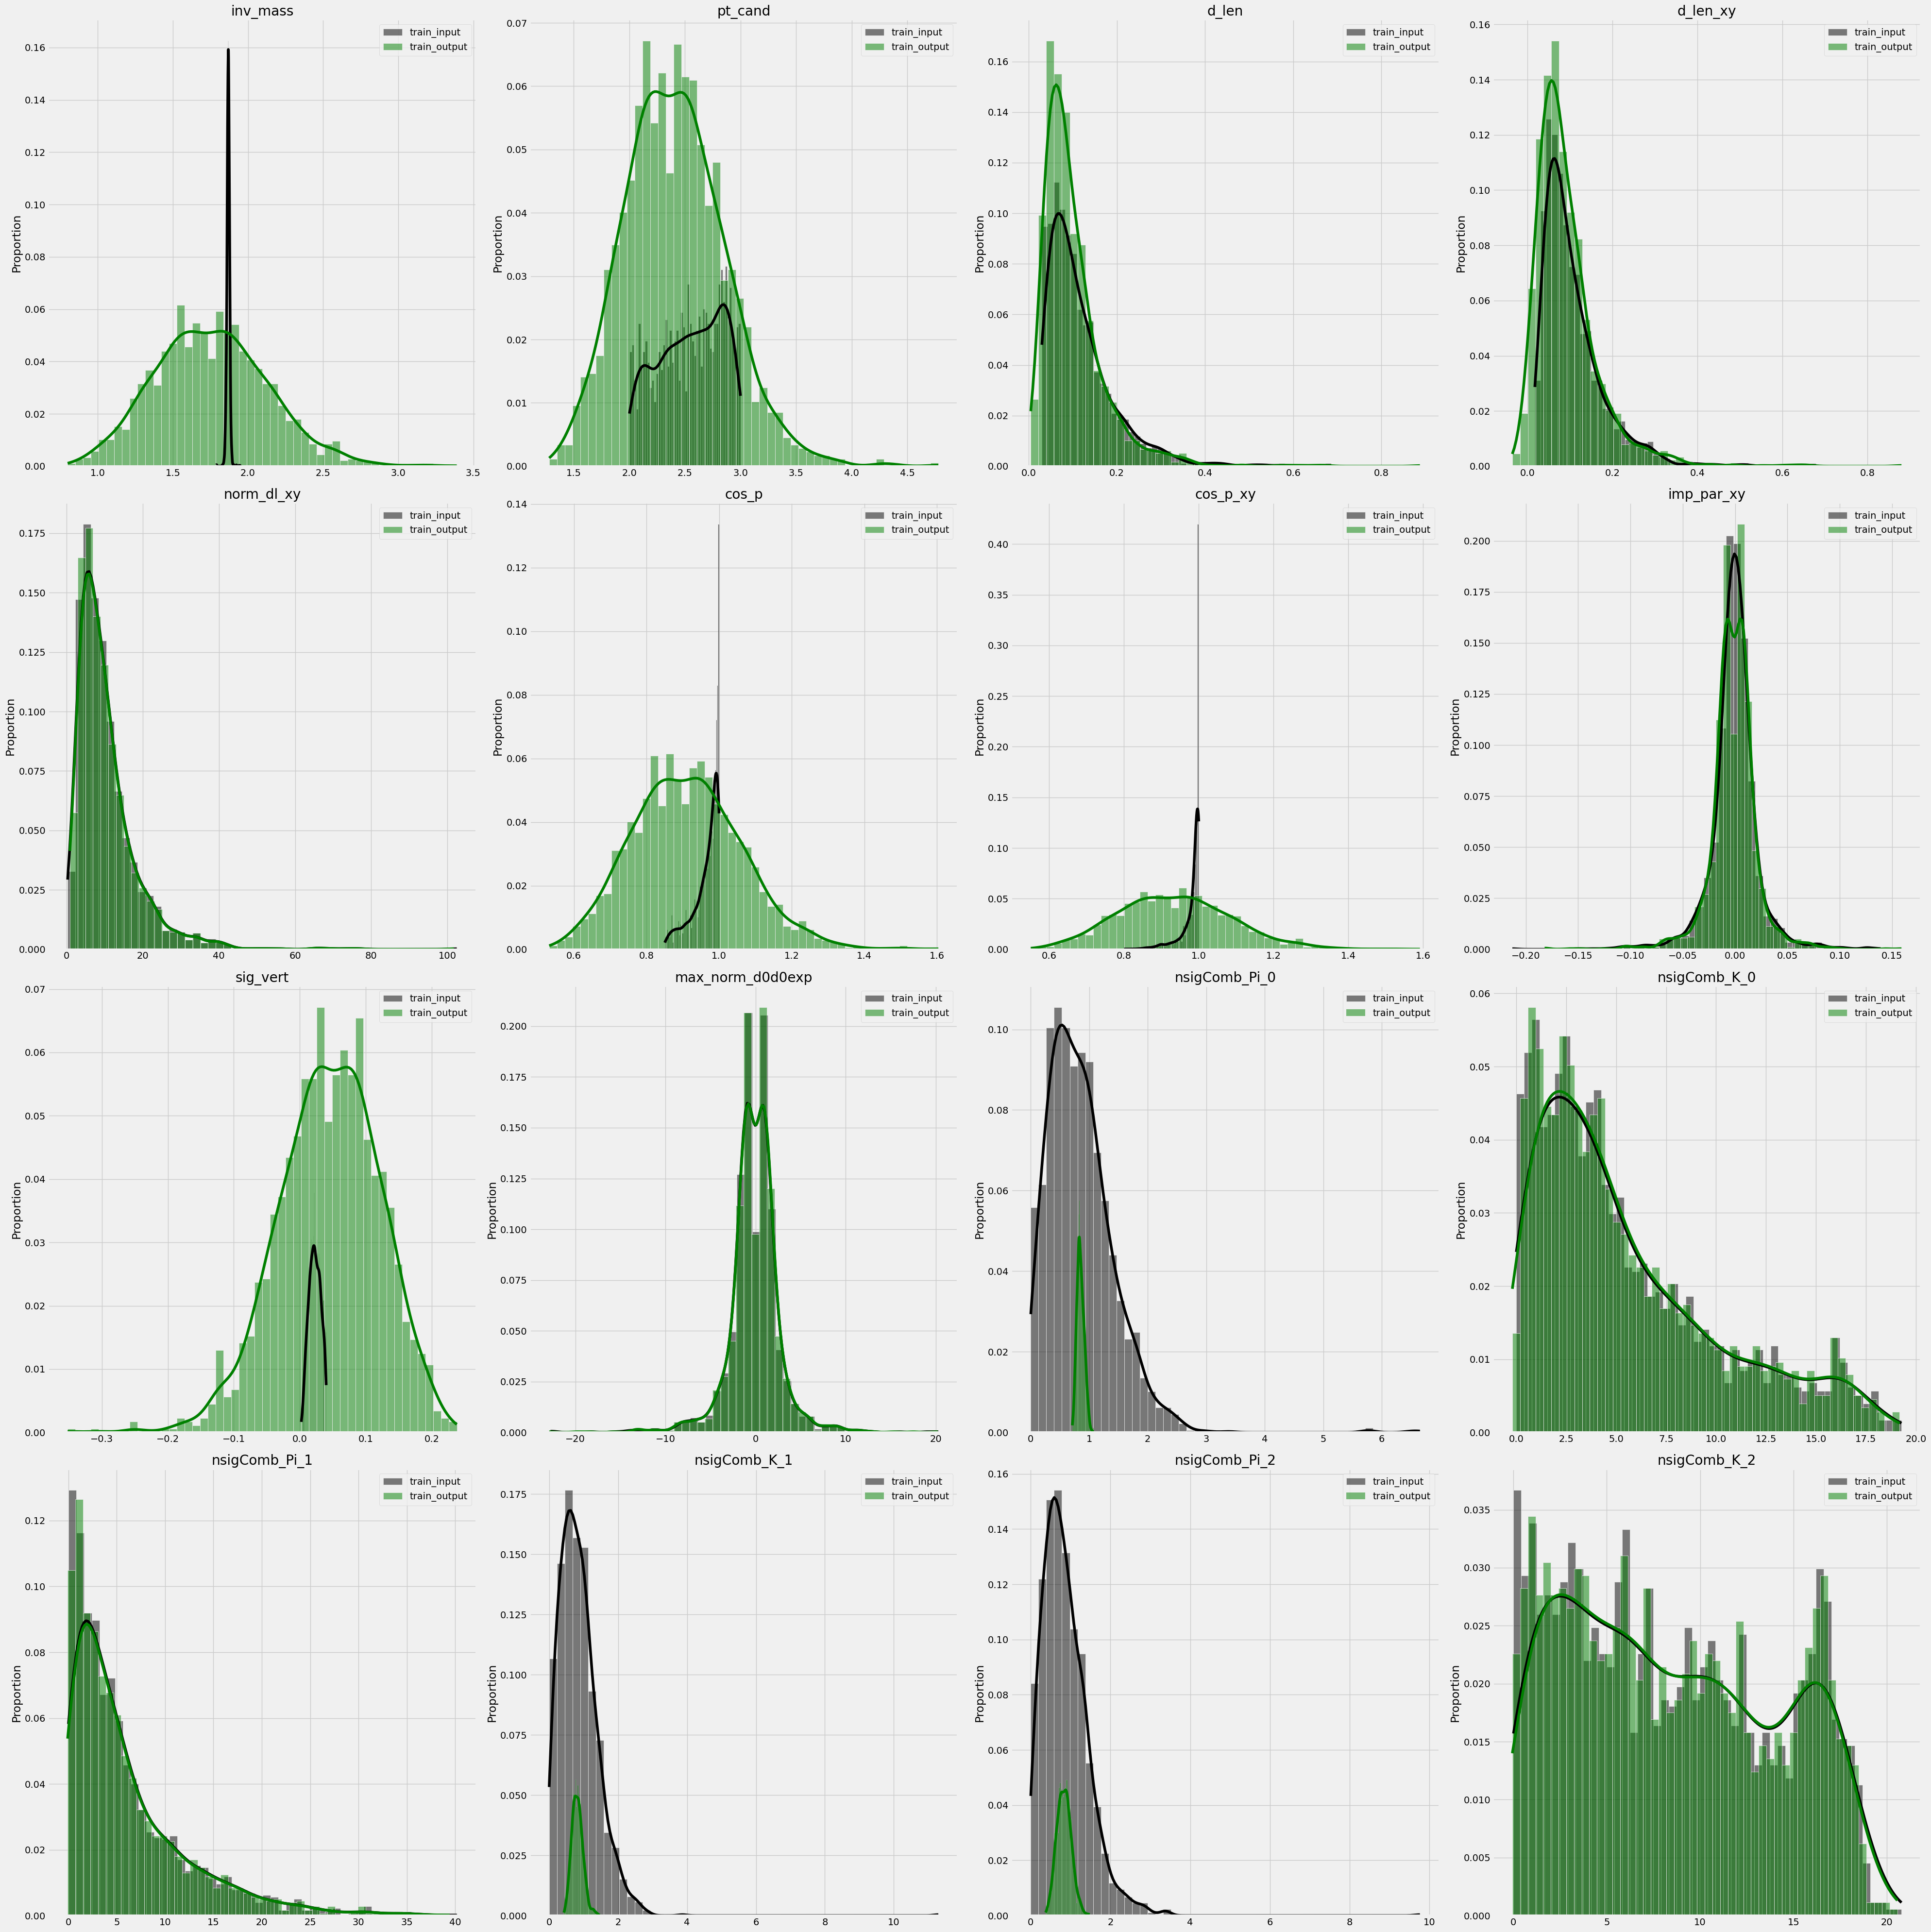

In [15]:

x = features.to(device).float()
with torch.no_grad():
    y = model_2D.forward(x)

x_test = features_test.to(device).float()
with torch.no_grad():
    y_test = model_2D.forward(x_test)


# Column names
columns = branches

# Plot histograms for each feature
fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()

for i, col in enumerate(columns):
    # sns.histplot(x_test[:,i], bins=50, color='blue', alpha=0.5, label='test_input', ax=axes[i],kde=True,stat='proportion')
    # sns.histplot(y_test[:,i], bins=50, color='red', alpha=0.5, label='test_output', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(x[:,i], bins=50, color='black', alpha=0.5, label='train_input', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(y[:,i], bins=50, color='green', alpha=0.5, label='train_output', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

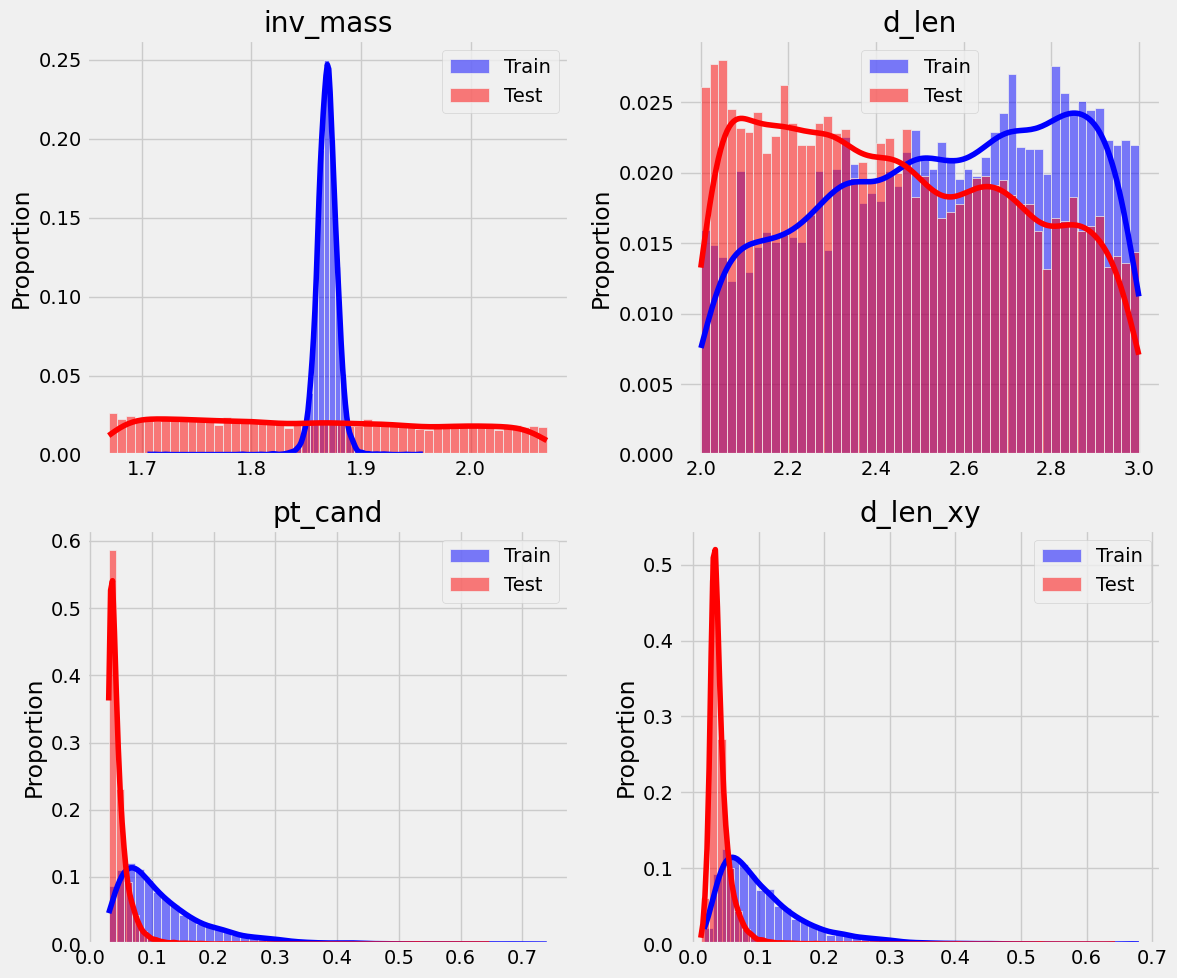

In [16]:
import seaborn as sns
def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)
# Convert train and test loaders
train_tensor = loader_to_tensor(loader)
test_tensor = loader_to_tensor(loader_test)

# Convert to numpy for plotting
train_np = train_tensor.numpy()
test_np = test_tensor.numpy()

# Column names
columns = ['inv_mass','d_len','pt_cand','d_len_xy']

# Plot histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(train_np[:, i], bins=50, color='blue', alpha=0.5, label='Train', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(test_np[:, i], bins=50, color='red', alpha=0.5, label='Test', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()